# 01. Problema, dataset y calidad de origen

**Responsable:** Gabriel Reyna · **Secciones de la guía:** 4.2.1, 4.2.2, apoyo a 4.2.4 y 4.2.7

Este notebook define el problema, documenta el dataset y demuestra con código cada afirmación sobre los datos: su cobertura, sus limitaciones, las reglas de limpieza propuestas y la referencia (baseline) que el modelo debe superar.

> Antes de subir cambios: *Kernel > Restart & Run All*.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor

from src import config
from src import limpieza
from src.baseline import ReglaMercadoM2
from src.datos import cargar_datos
from src.metricas import evaluar, errores_porcentuales, tabla_comparativa

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110

df = cargar_datos()
df["precio_m2"] = df["precio_usd"] / df["superficie_m2"]
print(f"{df.shape[0]:,} filas, {df.shape[1] - 1} columnas originales")

119,980 filas, 16 columnas originales


## 1. Definición del problema (4.2.1)

**Qué queremos lograr.** Estimar el precio de oferta en dólares de un departamento en Lima Metropolitana a partir de su ubicación y sus características, y comprobar si esa estimación es mejor que la regla que ya usa el mercado.

**Contexto.** En Lima, los departamentos se anuncian y negocian casi siempre en dólares. Quien vende fija el precio mirando anuncios parecidos del mismo distrito, y quien compra no tiene una referencia objetiva para saber si un precio es razonable. Además, el precio por m² cambió mucho en el tiempo (ver la tabla de abajo), así que una referencia de hace pocos años ya no sirve sin ajustes.

**Necesidad.** La referencia más usada es simple: "precio por m² típico del distrito × metraje". Esa regla ignora baños, cocheras, antigüedad y el momento del mercado. Un modelo que considere todo eso puede dar una referencia más precisa a compradores, vendedores y corredores.

**Unidad de análisis.** Un anuncio de venta de un departamento en un trimestre. Cada fila es un anuncio, no una venta concretada.

**Pregunta principal.** ¿Con qué error se puede estimar el precio de oferta en dólares de un departamento en Lima Metropolitana, usando su distrito, metraje, dormitorios, baños, cocheras, antigüedad y trimestre de publicación, para anuncios de los trimestres más recientes?

**Tipo de problema.** Regresión supervisada. La evaluación se hace sobre anuncios posteriores a los del entrenamiento, porque así se usaría el modelo en la vida real.

**Utilidad esperada.** Un comprador puede saber si un anuncio está caro o barato frente a otros parecidos; un vendedor, fijar un precio de lista razonable; un corredor, detectar precios mal ingresados.

**Criterios de utilidad.** El modelo será útil si:
1. Reduce el error frente a la regla de mercado (sección 6), no solo frente a un modelo trivial.
2. Baja el error porcentual mediano a 10% o menos (umbral propuesto, a validar en equipo).
3. Ningún distrito con volumen suficiente queda con error mediano mayor a 20%.

**Lo que el proyecto no responde.** No estima el precio final de venta, porque los datos son precios de anuncio. Tampoco explica causas: si los departamentos con cochera cuestan más, no podemos afirmar que la cochera "causa" el mayor precio.

In [2]:
# Evidencia del contexto: mediana de US$/m² en años clave
mediana_m2_anio = df.groupby("anio")["precio_m2"].median()
anios_clave = [1998, 2007, 2014, 2022, 2025]
print(mediana_m2_anio.loc[anios_clave].round(0).astype(int).to_string())
print(f"\n2007 -> 2014: el precio por m² se multiplicó por "
      f"{mediana_m2_anio[2014] / mediana_m2_anio[2007]:.2f}")

anio
1998     636
2007     558
2014    1592
2022    1606
2025    1804

2007 -> 2014: el precio por m² se multiplicó por 2.86


**Interpretación.** Entre 2007 y 2014 la mediana del precio por m² casi se triplicó; después se mantuvo estable hasta 2022 y volvió a subir. Esto confirma que el momento del anuncio es tan importante como sus características, y justifica evaluar el modelo con anuncios posteriores a los de entrenamiento. La evolución detallada se analiza en el EDA (notebook 02).

## 2. Dataset y procedencia (4.2.2)

| Campo | Valor |
| --- | --- |
| Fuente | Banco Central de Reserva del Perú (BCRP), base desagregada de precios de venta de departamentos |
| Origen del dato | 1998–2007: anuncios en periódicos. Hoy: portal Urbania ([BCRP, DT 006-2018](https://www.bcrp.gob.pe/docs/Publicaciones/Documentos-de-Trabajo/2018/documento-de-trabajo-006-2018.pdf); [BCRP, Nota de Estudios 65-2025](https://www.bcrp.gob.pe/docs/Publicaciones/Notas-Estudios/2025/nota-de-estudios-65-2025.pdf)) |
| Tipo de precio | Precio de oferta (lo que pide el vendedor), no precio de venta final |
| Variable objetivo | `precio_usd`: precio en dólares corrientes |
| Condiciones de uso | Dato público del BCRP. Pendiente: confirmar términos de uso de BCRPData |

Las cifras de tamaño, período y cobertura se calculan a continuación.

In [3]:
ficha = pd.Series({
    "Observaciones (filas)": f"{len(df):,}",
    "Variables (columnas)": df.shape[1] - 1,
    "Período": f"{df['periodo'].iloc[0]} a {df['periodo'].iloc[-1]} (trimestral)",
    "Años distintos": df["anio"].nunique(),
    "Distritos (escritura original)": df["distrito"].nunique(),
    "Distritos reales (tras unificar mayúsculas)": limpieza.normalizar_distritos(df)["distrito"].nunique(),
    "Filas duplicadas exactas": f"{df.drop(columns='precio_m2').duplicated().sum():,}",
})
ficha.to_frame("Valor")

,Valor
Observaciones (filas),"119,980"
Variables (columnas),16
Período,1998-1 a 2026-1 (trimestral)
Años distintos,29
Distritos (escritura original),44
Distritos reales (tras unificar mayúsculas),26
Filas duplicadas exactas,"2,730"


### Cobertura de distritos por período

El BCRP empezó con 5 distritos y fue ampliando la recolección. Esta tabla muestra cuántos anuncios hay de cada distrito en cada época.

In [4]:
dfn = limpieza.normalizar_distritos(df)
dfn["epoca"] = pd.cut(dfn["anio"], bins=[1997, 2007, 2021, 2026],
                      labels=["1998–2007", "2008–2021", "2022–2026"])
cobertura = pd.crosstab(dfn["distrito"], dfn["epoca"])
print("Distritos con anuncios en cada época:", (cobertura > 0).sum().to_dict())
cobertura.sort_values("1998–2007", ascending=False)

Distritos con anuncios en cada época: {'1998–2007': 15, '2008–2021': 19, '2022–2026': 26}


epoca,1998–2007,2008–2021,2022–2026
distrito,,,
Surco,4870,7582,5922
Miraflores,4069,7441,5997
San Borja,3128,4756,2565
La Molina,2901,4022,1570
San Isidro,2605,4970,2201
San Miguel,37,4973,3280
Magdalena,30,4130,2342
Jesús María,28,3406,2063
Pueblo Libre,25,3422,1867


**Interpretación.** Entre 1998 y 2007 casi todos los anuncios vienen de 5 distritos de ingresos altos (La Molina, Miraflores, San Borja, San Isidro y Surco). Ate, Comas y La Victoria solo aparecen desde 2022; entre 2008 y 2021 hay 19 distritos con anuncios. Un promedio de todo el período mezcla mercados distintos, por eso los análisis se hacen por época o incluyen el año.

### Por qué el objetivo es el precio en dólares y no en soles

Los departamentos se anuncian en dólares. Además, las columnas en soles son cálculos exactos a partir del precio en dólares; usarlas como entrada sería darle la respuesta al modelo (fuga de datos). Lo verificamos:

In [5]:
soles_es_usd_por_tc = np.allclose(df["precio_soles"], df["precio_usd"] * df["tipo_cambio"])
soles2009_es_soles_entre_ipc = np.allclose(df["precio_soles_2009"],
                                           df["precio_soles"] / df["ipc"] * 100, rtol=1e-3)
print("precio_soles == precio_usd × tipo_cambio:", soles_es_usd_por_tc)
print("precio_soles_2009 == precio_soles ÷ IPC × 100:", soles2009_es_soles_entre_ipc)
print("\nColumnas excluidas del modelo por fuga:", config.COLUMNAS_FUGA)
print("Columnas excluidas por redundantes con el período:", config.COLUMNAS_REDUNDANTES)

precio_soles == precio_usd × tipo_cambio: True
precio_soles_2009 == precio_soles ÷ IPC × 100: True

Columnas excluidas del modelo por fuga: ['precio_soles', 'precio_soles_2009']
Columnas excluidas por redundantes con el período: ['periodo', 'tipo_cambio', 'ipc']


**Interpretación.** Ambas igualdades se cumplen en todas las filas: las columnas en soles son el precio objetivo con otra unidad. El tipo de cambio y el IPC no son fuga (se conocen antes del anuncio), pero solo describen el trimestre, algo que `anio` y `trimestre` ya cubren.

## 3. Diccionario de variables

La descripción y el uso de cada variable son decisiones del equipo; los faltantes y rangos se calculan de los datos.

In [6]:
descripcion = {
    "periodo": ("Código de período, ej. '1998-1'", "Descartar: repite año y trimestre"),
    "anio": ("Año del anuncio", "Entrada"),
    "trimestre": ("Trimestre del anuncio", "Entrada"),
    "precio_usd": ("Precio pedido en US$ del momento", "OBJETIVO (modelar su logaritmo)"),
    "tipo_cambio": ("Soles por dólar del trimestre", "Descartar: redundante con el período"),
    "ipc": ("Índice de precios al consumidor (2009 = 100)", "Descartar: redundante con el período"),
    "precio_soles": ("Precio × tipo de cambio", "Descartar: FUGA de datos"),
    "precio_soles_2009": ("Precio en soles ÷ IPC × 100", "Descartar: FUGA de datos"),
    "distrito": ("Distrito del departamento", "Entrada (unificar escritura)"),
    "superficie_m2": ("Área en m²", "Entrada"),
    "habitaciones": ("Número de dormitorios", "Entrada"),
    "banos": ("Baños (0.5 = medio baño)", "Entrada"),
    "garajes": ("Número de cocheras", "Entrada"),
    "piso": ("Piso del departamento", "No usar en TP1: deja de registrarse desde 2019"),
    "vista_exterior": ("1 = vista a la calle", "No usar: constante desde 2022"),
    "antiguedad_anios": ("Edad del edificio (0 = estreno)", "Entrada"),
}
columnas = list(descripcion)
diccionario = pd.DataFrame({
    "Qué representa": [descripcion[c][0] for c in columnas],
    "Tipo": [str(df[c].dtype) for c in columnas],
    "Faltantes": [df[c].isna().sum() for c in columnas],
    "Mínimo": [df[c].min() if df[c].dtype != object else "" for c in columnas],
    "Mediana": [df[c].median() if df[c].dtype != object else "" for c in columnas],
    "Máximo": [df[c].max() if df[c].dtype != object else "" for c in columnas],
    "Valores distintos": [df[c].nunique() for c in columnas],
    "Uso": [descripcion[c][1] for c in columnas],
}, index=columnas)
diccionario

,Qué representa,Tipo,Faltantes,Mínimo,Mediana,Máximo,Valores distintos,Uso
periodo,"Código de período, ej. '1998-1'",object,0,,,,113,Descartar: repite año y trimestre
anio,Año del anuncio,int64,0,1998,2018.0,2026,29,Entrada
trimestre,Trimestre del anuncio,int64,0,1,3.0,4,4,Entrada
precio_usd,Precio pedido en US$ del momento,float64,0,190.0,126250.935821,3420000.0,13807,OBJETIVO (modelar su logaritmo)
tipo_cambio,Soles por dólar del trimestre,float64,0,2.574636,3.393714,4.044573,113,Descartar: redundante con el período
ipc,Índice de precios al consumidor (2009 = 100),float64,0,73.129821,129.501577,169.177118,113,Descartar: redundante con el período
precio_soles,Precio × tipo de cambio,float64,0,702.837783,434179.027113,11372361.424394,39620,Descartar: FUGA de datos
precio_soles_2009,Precio en soles ÷ IPC × 100,float64,0,438.926157,326938.556228,9074998.508478,39620,Descartar: FUGA de datos
distrito,Distrito del departamento,object,0,,,,44,Entrada (unificar escritura)
superficie_m2,Área en m²,float64,0,15.24,96.0,950.0,3212,Entrada


**Interpretación.** De las 16 columnas, 8 entran al modelo, 1 es el objetivo y 7 se descartan. Los valores extremos visibles (precio mínimo de US$190, antigüedad máxima de 1996 años, vista_exterior con máximo 11) son errores de digitación que se tratan en la sección 5. El baño de 0.5 sí es válido: corresponde a un medio baño o baño de visita.

## 4. Limitaciones del dataset

### Dos variables dejan de registrarse

Si el 0 en `piso` significara "primer piso", su proporción sería estable en el tiempo. Revisamos por año qué porcentaje de anuncios tiene `piso` en 0 o vacío, y qué porcentaje tiene `vista_exterior` = 1.

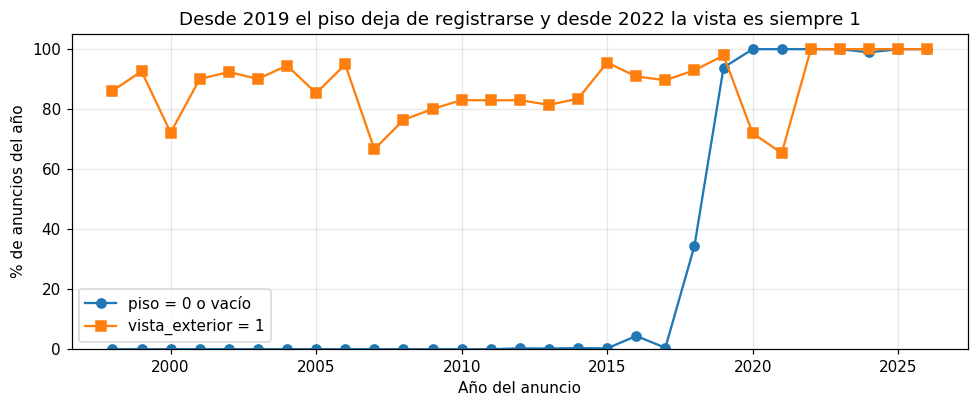

Desde 2019: 58,175 de 58,639 anuncios tienen piso 0 o vacío
Desde 2022: 100.0% de anuncios tienen vista = 1


In [7]:
por_anio = df.groupby("anio").agg(
    piso_0_o_vacio=("piso", lambda s: ((s == 0) | s.isna()).mean()),
    vista_igual_1=("vista_exterior", lambda s: (s == 1).mean()),
)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(por_anio.index, por_anio["piso_0_o_vacio"] * 100, marker="o", label="piso = 0 o vacío")
ax.plot(por_anio.index, por_anio["vista_igual_1"] * 100, marker="s", label="vista_exterior = 1")
ax.set_ylabel("% de anuncios del año")
ax.set_xlabel("Año del anuncio")
ax.set_title("Desde 2019 el piso deja de registrarse y desde 2022 la vista es siempre 1")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIGURES / "01_piso_vista_por_anio.png")
plt.show()

desde_2019 = df[df["anio"] >= 2019]
print(f"Desde 2019: {((desde_2019['piso'] == 0) | desde_2019['piso'].isna()).sum():,} "
      f"de {len(desde_2019):,} anuncios tienen piso 0 o vacío")
desde_2022 = df[df["anio"] >= 2022]
print(f"Desde 2022: {(desde_2022['vista_exterior'] == 1).mean():.1%} de anuncios tienen vista = 1")

**Lo que muestran los datos.** Hasta 2017 el piso casi nunca es 0; desde 2019 es 0 o vacío en casi todos los anuncios. La vista al exterior vale 1 en todos los anuncios desde 2022.

**Lo que interpretamos.** El 0 no significa "primer piso" sino "no registrado". El cambio coincide con el paso de la recolección a portales web, pero el BCRP no lo documenta, así que es una hipótesis. Si el modelo usara `piso` tal cual, aprendería que "piso 0" equivale a "anuncio reciente y caro", una relación falsa. Por eso proponemos no usar `piso` ni `vista_exterior` en el TP1.

### Faltantes concentrados en ciertos años

In [8]:
faltantes_por_anio = (
    df[["garajes", "antiguedad_anios", "piso", "vista_exterior"]]
    .isna().groupby(df["anio"]).mean()
)
faltantes_por_anio[faltantes_por_anio.sum(axis=1) > 0].style.format("{:.0%}")

,garajes,antiguedad_anios,piso,vista_exterior
anio,,,,
2014,0%,0%,0%,0%
2015,0%,0%,0%,0%
2016,0%,0%,0%,0%
2017,0%,0%,0%,0%
2018,5%,10%,14%,3%
2019,25%,24%,0%,2%
2020,0%,0%,27%,27%
2021,0%,0%,35%,35%


**Interpretación.** Los faltantes no están repartidos al azar: casi no existen antes de 2018 y se concentran entre 2018 y 2021, justo en la transición de la forma de recolección. Imputarlos con una mediana general sin avisar al modelo ocultaría esa diferencia; por eso la regla 10 agrega una columna que marca que el dato faltaba.

## 5. Reglas de limpieza propuestas (apoyo a 4.2.4)

Cada regla se cuenta sobre los datos. Las reglas 1 a 8 corrigen errores de los datos; la 9 depende de medianas y se ajusta solo con el entrenamiento; la 10 va dentro del pipeline (notebook 03). La implementación está en `src/limpieza.py` para que José la reutilice.

In [9]:
d = df.drop(columns="precio_m2")
dn = limpieza.normalizar_distritos(d)
conteo_distrito = dn["distrito"].value_counts()
distritos_raros = conteo_distrito[conteo_distrito == 1].index.tolist()
banos_raros = d["banos"].notna() & ((d["banos"] * 2) % 1 != 0)

# Regla 9, solo como diagnóstico: medianas del entrenamiento sobre datos sin duplicados
dn_sin_dup = limpieza.eliminar_duplicados(dn)
train_diag = dn_sin_dup[dn_sin_dup["anio"] <= config.ANIO_FIN_TRAIN]
test_diag = dn_sin_dup[dn_sin_dup["anio"] >= config.ANIO_INICIO_TEST]
filtro_diag = limpieza.FiltroPrecioM2Extremo().fit(train_diag)
extremos = filtro_diag.es_extremo(train_diag).sum() + filtro_diag.es_extremo(test_diag).sum()

reglas = pd.DataFrame([
    ("Duplicados exactos", d.duplicated().sum(), "Eliminar ANTES de separar train y test"),
    ("Distrito mal escrito", (dn["distrito"] != d["distrito"]).sum(), "Unificar escritura"),
    ("Distritos con 1 sola fila", len(distritos_raros), "Agrupar como 'Otros' o eliminar"),
    ("Piso 0 o vacío desde 2019", ((d["anio"] >= 2019) & ((d["piso"] == 0) | d["piso"].isna())).sum(),
     "No usar la variable en el TP1"),
    ("Vista = 1 en 2022–2026", ((d["anio"] >= 2022) & (d["vista_exterior"] == 1)).sum(),
     "No usar la variable"),
    ("Vista con valor distinto de 0 y 1", (~d["vista_exterior"].isin([0, 1]) & d["vista_exterior"].notna()).sum(),
     "Tratar como faltante"),
    ("Baños con decimal inválido (ej. 2.54)", banos_raros.sum(), "Tratar como faltante"),
    ("Antigüedad mayor a 150 años", (d["antiguedad_anios"] > 150).sum(), "Tratar como faltante"),
    ("US$/m² < 25% o > 4 veces la mediana de su distrito y año", extremos,
     "Eliminar (medianas del entrenamiento)"),
    ("Faltantes en garajes / antigüedad", f"{d['garajes'].isna().sum():,} / {d['antiguedad_anios'].isna().sum():,}",
     "Imputar con mediana del train + columna 'era faltante'"),
], columns=["Problema", "Filas afectadas", "Decisión propuesta"], index=range(1, 11))
print("Distritos con 1 sola fila:", distritos_raros)
print("Valores de baños inválidos:", sorted(d.loc[banos_raros, "banos"].unique()))
reglas

Distritos con 1 sola fila: ['Callao', 'San Juan de Lurigancho', 'San Luis', 'San Martín de Porres']
Valores de baños inválidos: [np.float64(1.1), np.float64(1.8), np.float64(2.54), np.float64(2.56), np.float64(2.6), np.float64(3.05), np.float64(3.2), np.float64(3.25), np.float64(3.58), np.float64(4.1)]


,Problema,Filas afectadas,Decisión propuesta
1,Duplicados exactos,2730,Eliminar ANTES de separar train y test
2,Distrito mal escrito,147,Unificar escritura
3,Distritos con 1 sola fila,4,Agrupar como 'Otros' o eliminar
4,Piso 0 o vacío desde 2019,58175,No usar la variable en el TP1
5,Vista = 1 en 2022–2026,41523,No usar la variable
6,Vista con valor distinto de 0 y 1,1,Tratar como faltante
7,Baños con decimal inválido (ej. 2.54),12,Tratar como faltante
8,Antigüedad mayor a 150 años,1,Tratar como faltante
9,US$/m² < 25% o > 4 veces la mediana de su distrito y año,80,Eliminar (medianas del entrenamiento)
10,Faltantes en garajes / antigüedad,"1,551 / 1,722",Imputar con mediana del train + columna 'era faltante'


**Por qué cada decisión.**
- **Duplicados antes de separar:** si el mismo anuncio queda en train y en test, el modelo lo "memoriza" y la métrica sale mejor de lo que es.
- **Precio por m² relativo a su distrito y año:** US$400/m² era normal en 2003 y absurdo en 2024; un umbral fijo eliminaría anuncios reales antiguos.
- **Medianas solo del entrenamiento:** calcularlas con todo el dataset usaría información del test.
- **Columna "era faltante":** los faltantes dependen del año, y el modelo debe poder distinguir un dato imputado de uno real.

**Pendiente para el equipo:** confirmar estas reglas con el EDA de Yair y decidir si el modelo se entrena con todos los años o solo desde 2008.

## 6. Baseline de dominio y criterio de utilidad (apoyo a 4.2.7)

**Pregunta:** ¿cuánto se equivoca la regla que ya usa el mercado? Esa es la vara real que el modelo debe superar, más exigente que un modelo trivial.

**Cómo lo medimos:**
1. Aplicamos las reglas 1, 2 y 9.
2. Separamos por tiempo: entrenamiento hasta 2023 y evaluación desde 2024, como se usaría el modelo en la práctica.
3. Comparamos dos DummyRegressor (media y mediana) con la regla de mercado: mediana de US$/m² de cada distrito en el último año de entrenamiento × metraje.

In [10]:
datos = limpieza.eliminar_duplicados(limpieza.normalizar_distritos(df.drop(columns="precio_m2")))
train = datos[datos["anio"] <= config.ANIO_FIN_TRAIN]
test = datos[datos["anio"] >= config.ANIO_INICIO_TEST]

filtro = limpieza.FiltroPrecioM2Extremo().fit(train)
train = train[~filtro.es_extremo(train)]
test = test[~filtro.es_extremo(test)]
print(f"Entrenamiento: {len(train):,} anuncios ({train['anio'].min()}–{train['anio'].max()})")
print(f"Evaluación:    {len(test):,} anuncios ({test['anio'].min()}–{test['anio'].max()})")

X_cols = ["anio", "distrito", "superficie_m2"]
modelos = {
    "DummyRegressor (media)": DummyRegressor(strategy="mean"),
    "DummyRegressor (mediana)": DummyRegressor(strategy="median"),
    "Regla de mercado (distrito × m²)": ReglaMercadoM2(anios_referencia=1),
}
resultados, predicciones = {}, {}
for nombre, modelo in modelos.items():
    modelo.fit(train[X_cols], train[config.OBJETIVO])
    predicciones[nombre] = modelo.predict(test[X_cols])
    resultados[nombre] = evaluar(test[config.OBJETIVO], predicciones[nombre])
tabla_comparativa(resultados)

Entrenamiento: 92,004 anuncios (1998–2023)
Evaluación:    25,161 anuncios (2024–2026)


,MAE (US$),RMSE (US$),Error % mediano,Error % medio (MAPE),Anuncios con error <= 10%
DummyRegressor (media),"53,868","70,917",27.7%,36.6%,17.3%
DummyRegressor (mediana),"59,903","81,544",31.6%,34.3%,17.0%
Regla de mercado (distrito × m²),"29,183","40,003",15.0%,18.6%,34.3%


**Interpretación.** La regla de mercado reduce el error a la mitad frente a los Dummy: un anuncio típico queda a 15% de su precio real, contra 28–32% del modelo trivial, y el error absoluto medio baja de unos US$54–60 mil a unos US$29 mil. Superar al Dummy no demostraría nada útil; el modelo debe superar el 15% de la regla.

Las métricas se eligieron por el uso real: el **MAE en dólares** es lo que entiende un comprador; el **error porcentual mediano** describe un anuncio típico sin que unos pocos errores de digitación lo distorsionen; el **% de anuncios con error ≤ 10%** indica qué tan seguido la estimación sirve para negociar.

### ¿Dónde falla más la regla?

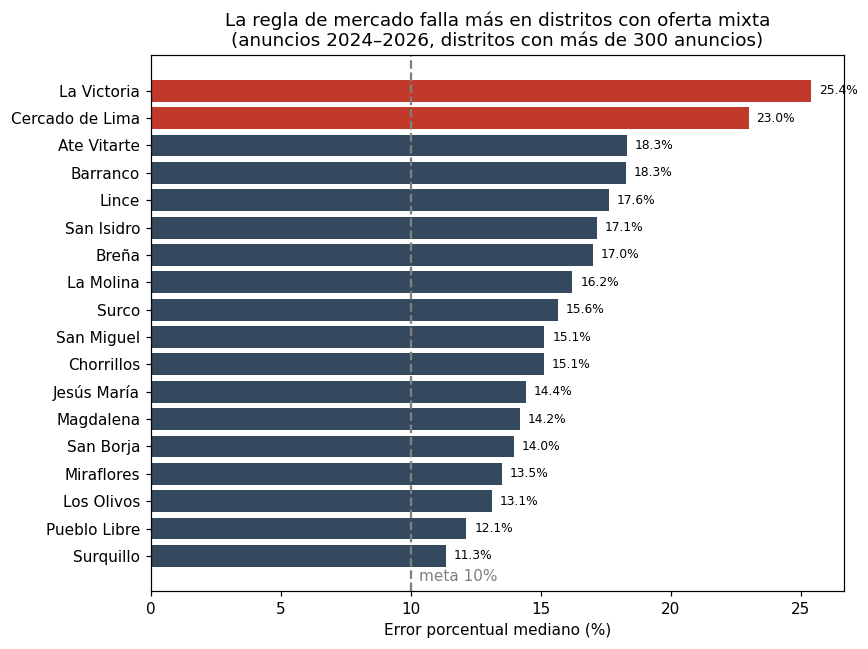

In [11]:
regla = "Regla de mercado (distrito × m²)"
por_distrito = (
    pd.DataFrame({"distrito": test["distrito"].to_numpy(),
                  "error": errores_porcentuales(test[config.OBJETIVO], predicciones[regla])})
    .groupby("distrito")["error"].agg(["median", "size"])
)
por_distrito = por_distrito[por_distrito["size"] > 300].sort_values("median")

fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#c0392b" if v > 0.20 else "#34495e" for v in por_distrito["median"]]
ax.barh(por_distrito.index, por_distrito["median"] * 100, color=colores)
ax.axvline(10, ls="--", color="gray")
ax.text(10.3, -0.9, "meta 10%", color="gray")
ax.set_xlabel("Error porcentual mediano (%)")
ax.set_title("La regla de mercado falla más en distritos con oferta mixta\n(anuncios 2024–2026, distritos con más de 300 anuncios)")
for i, v in enumerate(por_distrito["median"]):
    ax.text(v * 100 + 0.3, i, f"{v:.1%}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES / "01_error_regla_por_distrito.png")
plt.show()

**Lo que muestran los datos.** La regla funciona mejor en Surquillo y Pueblo Libre (error mediano cercano a 11–12%) y peor en Cercado de Lima y La Victoria (más de 20%).

**Lo que interpretamos.** En los distritos donde falla, conviven edificios muy distintos, así que el precio por m² del distrito no representa bien a cada departamento. Ahí es donde baños, cocheras y antigüedad deberían ayudar al modelo. Es una hipótesis que se comprueba en el notebook 03 comparando el error por distrito del modelo con este.

### Criterio de utilidad

El modelo será útil si baja el error porcentual mediano de **15% a 10% o menos** y si ningún distrito con más de 300 anuncios queda por encima de **20%**. El umbral de 10% es una propuesta del equipo y falta respaldarlo con una fuente sobre márgenes de negociación en Lima.

## 7. Resumen del bloque

- El dataset tiene 119,980 anuncios (1998–2026) del BCRP, con precios de oferta, no de venta final.
- La cobertura cambia en el tiempo: 5 distritos hasta 2007 y 26 en 2022–2026.
- `piso` y `vista_exterior` dejan de registrarse desde 2019 y 2022; no se usan en el TP1.
- Las columnas en soles son el objetivo convertido: se excluyen por fuga de datos.
- La regla de mercado ya logra 15% de error mediano; esa es la vara que el modelo debe superar.

**Pendiente:** validar las reglas de limpieza con el EDA, confirmar el umbral de 10% y agregar el enlace exacto de descarga del dataset.